In [25]:
# Import necessary libraries
import numpy as np
import pandas as pd
import math
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Concatenate, LSTM, Dense, Bidirectional, Dropout, Input, TimeDistributed, MultiHeadAttention, LayerNormalization, Conv1D, MaxPooling1D, Attention, GlobalAveragePooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.metrics import AUC 
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score  

In [9]:
# Step 1: Remove all the Proteins whose aminoacid sequences have less than X number of characters
def filter_sequences(df, sequence_column, min_length):
    mask = df[sequence_column].str.len() >= min_length
    filtered_df = df[mask].reset_index(drop = True)
    return filtered_df

# Step 1.1: Load your dataset of cancer-related proteins and their AA sequences
# CSV file with 'ProteinID' and 'AminoAcidSequence' columns
data = pd.read_csv("protein_dataset.csv")

data = data.iloc[:10001]
data = filter_sequences(data, "AminoacidSequence", 90)

# Data format: ProteinID | AminoAcidSequence
# Protein_1 | MGVLTLTGGKGAAGVG
# Protein_2 | MPYQKVGFYKPVEF

#print(data["ProteinID"].head())
#print(data["AminoacidSequence"].head())
#print(data["SecondaryStructure"].head())
print(data.tail())

     ProteinID                                  AminoacidSequence  \
8622  3BBC_1_A  ANLERTFIAIKPDGVQRGLVGEIIKRFEQKGFRLVAMKFLRASEEH...   
8623  3BBD_1_A  MTYNIILAKSALELIPEEIKNKIRKSRVYKYDILDSNYHYKAMEKL...   
8624  3BBE_1_A  MTYNIILAKSALELIPEEIKNKIRKSRVYKYDILDSNYHYKAMEKL...   
8625  3BBF_1_A  ANLERTFIAIKPDGVQRGLVGEIIKRFEQKGFRLVAMKFLRASEEH...   
8626  3BBH_1_A  MTYNIILAKSALELIPEEIKNKIRKSRVYKYDILDSNYHYKAMEKL...   

                                     SecondaryStructure  
8622  LTTLEEEEEELHHHHHTTLHHHHHHHHHHHTLEEEEEEEELLLHHH...  
8623  LLEEEEEEEESLLBLLGGGGGGLLLBTTBLLSBLLHHHHTTTTTTL...  
8624  LLEEEEEEEESLLBLLGGGGGGLLLBTTBLLSBLLHHHHTGGGTTL...  
8625  LTTLEEEEEELHHHHHTTLHHHHHHHHHHHTLEEEEEEEELLLHHH...  
8626  LLEEEEEEEESLLBLLHHHHTTLLLLSSLLLSBLLHHHHTGGGTTL...  


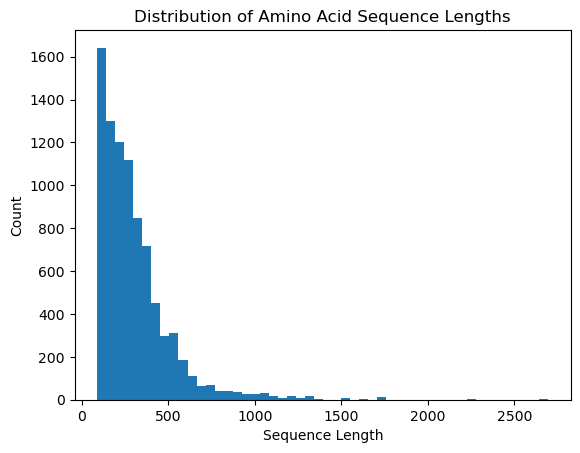

In [10]:
# Analyze your sequence length distribution: Plot a histogram to see the spread
lengths = data["AminoacidSequence"].apply(len)

plt.hist(lengths, bins = 50)
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Distribution of Amino Acid Sequence Lengths")
plt.show()

In [11]:
# Step 2: Secondary structure prediction (this part needs PSIPRED or similar tool)
# Format for 'SecondaryStructure':
# data['SecondaryStructure'] = ['EEEHHHCCCCC', 'HHHEEECCCC', ...]

# Step 3: Map secondary structure labels (H, E, C) to numbers
def map_structure_to_numbers(structure):
    # Map each secondary structure type to a corresponding number
    return [0 if char == "H" else 
            1 if char in ["E", "B"] else 
            2 # replace with a 2 if its any other character/letter there
            for char in structure
]

data["MappedStructure"] = data["SecondaryStructure"].apply(map_structure_to_numbers)
#print(data["MappedStructure"].head())
print(data["MappedStructure"].tail())

8622    [2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, ...
8623    [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, ...
8624    [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, ...
8625    [2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, ...
8626    [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, ...
Name: MappedStructure, dtype: object


In [12]:
# Step 4: One-hot encode the secondary structure labels (Helix = 0, Sheet = 1, Coil = 2)
def one_hot_encode(structure):
    # Encode structure as one-hot vector: [0, 1, 0] for Helix, [1, 0, 0] for Sheet, [0, 0, 1] for Coil
    return [[1, 0, 0] if val == 0 else 
            [0, 1, 0] if val == 1 else 
            [0, 0, 1] # replace with this cell if there is any other number
            for val in structure
]

data["OneHotEncodedStructure"] = data["MappedStructure"].apply(one_hot_encode)
#print(data["OneHotEncodedStructure"].head())
print(data["OneHotEncodedStructure"].tail())

8622    [[0, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1], [...
8623    [[0, 0, 1], [0, 0, 1], [0, 1, 0], [0, 1, 0], [...
8624    [[0, 0, 1], [0, 0, 1], [0, 1, 0], [0, 1, 0], [...
8625    [[0, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1], [...
8626    [[0, 0, 1], [0, 0, 1], [0, 1, 0], [0, 1, 0], [...
Name: OneHotEncodedStructure, dtype: object


In [13]:
# Step 5: Prepare the input and output data for the LSTM model
# The input will be the amino acid sequences, and the output will be the one-hot encoded secondary structure

# Convert AA sequences into a format suitable for the model
# Create a dictionary of all possible amino acids
aa_dict = {
    'A': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Alanine
    'C': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Cysteine
    'D': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Aspartic acid
    'E': [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Glutamic acid
    'F': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Phenylalanine
    'G': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Glycine
    'H': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Histidine
    'I': [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Isoleucine
    'K': [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Lysine
    'L': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Leucine
    'M': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Methionine
    'N': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # Asparagine
    'P': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # Proline
    'Q': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # Glutamine
    'R': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # Arginine
    'S': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # Serine
    'T': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # Threonine
    'V': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # Valine
    'W': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],  # Tryptophan
    'Y': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],  # Tyrosine
}

def encode_aa_sequence(sequence):
    return [aa_dict[aa] for aa in sequence if aa in aa_dict]


In [26]:
# Apply encoding to amino acid sequences
X = data["AminoacidSequence"].apply(encode_aa_sequence)

# Dynamically determine the maximum sequence length
max_sequence_length = min(300, np.percentile(X.apply(len), 98).astype(int)) # Use the 98th percentile to set max_sequence_length to prevent unnecessary zeros

# Convert to a uniform NumPy array after padding
X = pad_sequences(X.to_list(), maxlen=max_sequence_length, dtype="float32", padding = "post")

# Prepare output labels: ensure consistency for y
y = data["OneHotEncodedStructure"].to_list()  # Extract the list of lists for y
y = pad_sequences(y, maxlen=max_sequence_length, dtype="float32", padding = "post")

# Split into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Model definition
inputs = Input(shape=(max_sequence_length, 20))

x = Bidirectional(LSTM(128, return_sequences = True, kernel_regularizer=l2(1e-4), recurrent_dropout = 0.3))(inputs)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Bidirectional(LSTM(64, return_sequences = True, kernel_regularizer=l2(1e-4), recurrent_dropout = 0.3))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Bidirectional(LSTM(32, return_sequences = True, kernel_regularizer=l2(1e-4), recurrent_dropout = 0.3))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

outputs = TimeDistributed(Dense(3, activation="sofmax", kernel_regularizer=l2(1e-4)))(x)
model = Model(inputs=inputs, outputs=outputs)

# Adjusted learning rate scheduler
reduce_lr = ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = 5, min_lr = 1e-6, verbose = 1)

# Compile the model
model.compile(optimizer = Adam(learning_rate = 0.001, weight_decay = 1e-4), loss = "categorical_crossentropy", metrics = ["accuracy", AUC(name = "auc")])

# Define callbacks
lr_scheduler = reduce_lr
early_stopping = EarlyStopping(monitor = "val_loss", patience = 6, restore_best_weights = True)

# Train the model with history to capture metrics for plotting
history = model.fit(
    X_train, y_train,
    epochs = 50,
    batch_size = 64,
    validation_split = 0.2,
    callbacks = [tf.keras.callbacks.ModelCheckpoint(
            filepath = "best_model.keras",
            monitor = "val_loss",
            save_best_only = True, 
            mode = "min",
            verbose = 1
        ),
        lr_scheduler, 
        early_stopping]
)

# Evaluate the model
loss, accuracy, auc = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}, Test AUC: {auc}")

# Calculate F1 Score
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis = -1).flatten()
y_true = np.argmax(y_test, axis = -1).flatten()

f1 = f1_score(y_true, predictions, average = "macro")  # Macro average for multi-class
print(f"Test F1 Score: {f1}")

# Save the model
model.save("improved_protein_secondary_structure_model_adam.h5")

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4827 - auc: 0.6679 - loss: 0.9900
Epoch 1: val_loss improved from inf to 0.84789, saving model to best_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.4833 - auc: 0.6684 - loss: 0.9885 - val_accuracy: 0.4185 - val_auc: 0.7183 - val_loss: 0.8479 - learning_rate: 0.0010
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5789 - auc: 0.7613 - loss: 0.7326
Epoch 2: val_loss improved from 0.84789 to 0.80176, saving model to best_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.5790 - auc: 0.7614 - loss: 0.7324 - val_accuracy: 0.3700 - val_auc: 0.7300 - val_loss: 0.8018 - learning_rate: 0.0010
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6046 - auc: 0.7808 - loss: 0.6888
Epoch 3: val_loss improved from 0.80176 to 0.75664, saving model to best_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.6046 - auc: 0.7808 - loss: 0.6887 - val_accuracy: 0.5489 - v

Test F1 Score: 0.7631904725649267


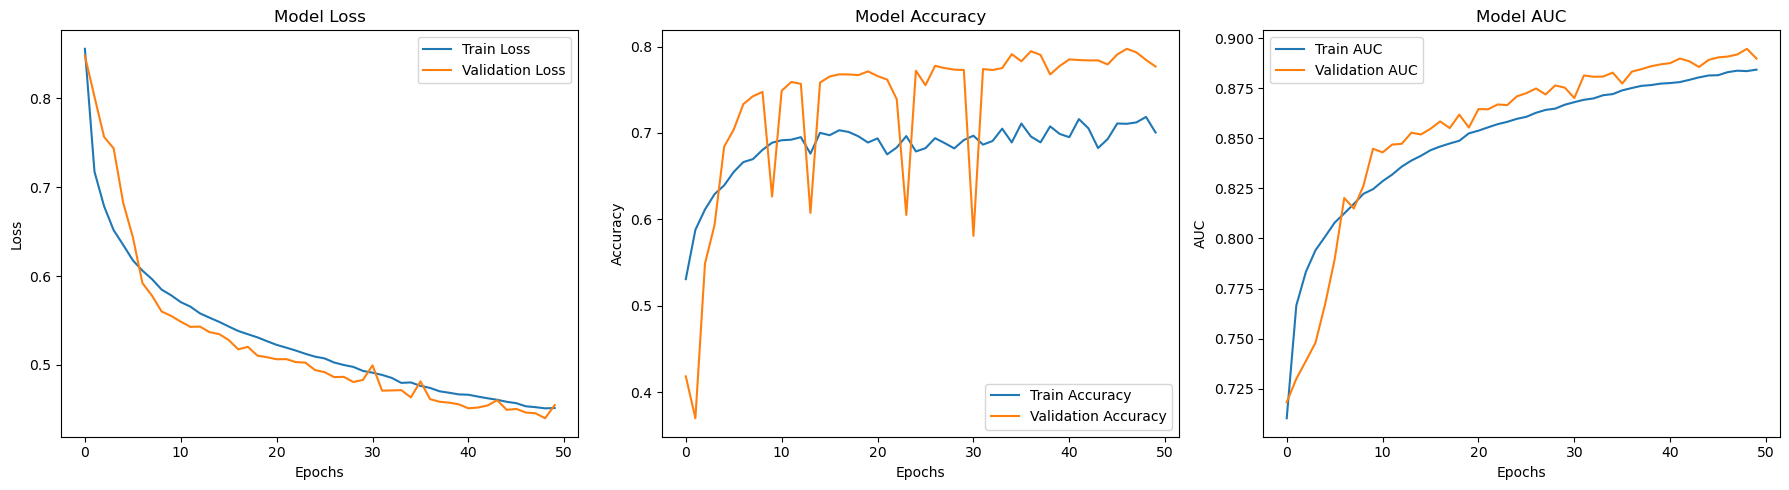

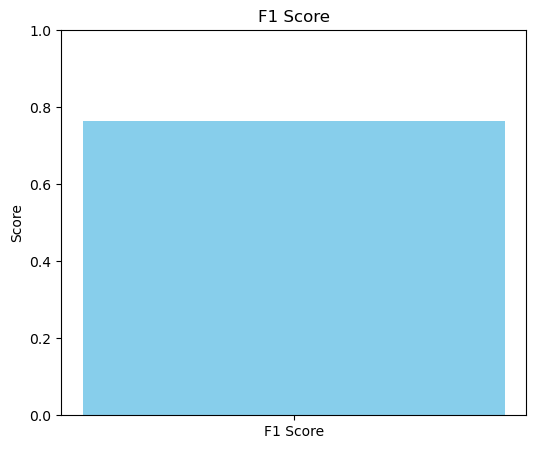

In [27]:
# Plot accuracy, loss, and AUC
plt.figure(figsize=(18, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label = "Train Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(history.history["accuracy"], label = "Train Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# AUC plot
if "auc" in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history["auc"], label = "Train AUC")
    plt.plot(history.history["val_auc"], label = "Validation AUC")
    plt.title("Model AUC")
    plt.xlabel("Epochs")
    plt.ylabel("AUC")
    plt.legend()

plt.tight_layout()
plt.show()

# F1 Score Visualization
plt.figure(figsize = (6, 5))
plt.bar(["F1 Score"], [f1], color = "skyblue")
plt.title("F1 Score")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.show()